In [26]:
import json 
import os
ROOT_DIR = "/Users/ppruthi/research/CLeaR_codebase/compositional_models_cate/synthetic_data"


parallel_results_json = "/Users/ppruthi/research/CLeaR_codebase/compositional_models_cate/synthetic_data/results/systematic_True/all_results_uniform_parallel_covariates_shared_False_use_subset_features_False_combined_results_sequential_exp_CG_number_of_modules_10.json"
sequential_results_json = "/Users/ppruthi/research/CLeaR_codebase/compositional_models_cate/synthetic_data/results/systematic_True/all_results_uniform_sequential_covariates_shared_False_use_subset_features_False_combined_results_sequential_exp_CG_number_of_modules_10_all_baselines.json"
with open(sequential_results_json) as f:
    seq_results = json.load(f)

with open(parallel_results_json) as f:
    parallel_results = json.load(f)

# make plots directory
os.system("mkdir -p plots")

0

# Sequential Compositional Generalization

[-0.11902507176815558]
[2]
[0.9939409622872846]
[2]
[0.9831654193086665]
[2]
[0.8710430475864894]
[2]
[0.6393159364306813]
[2]


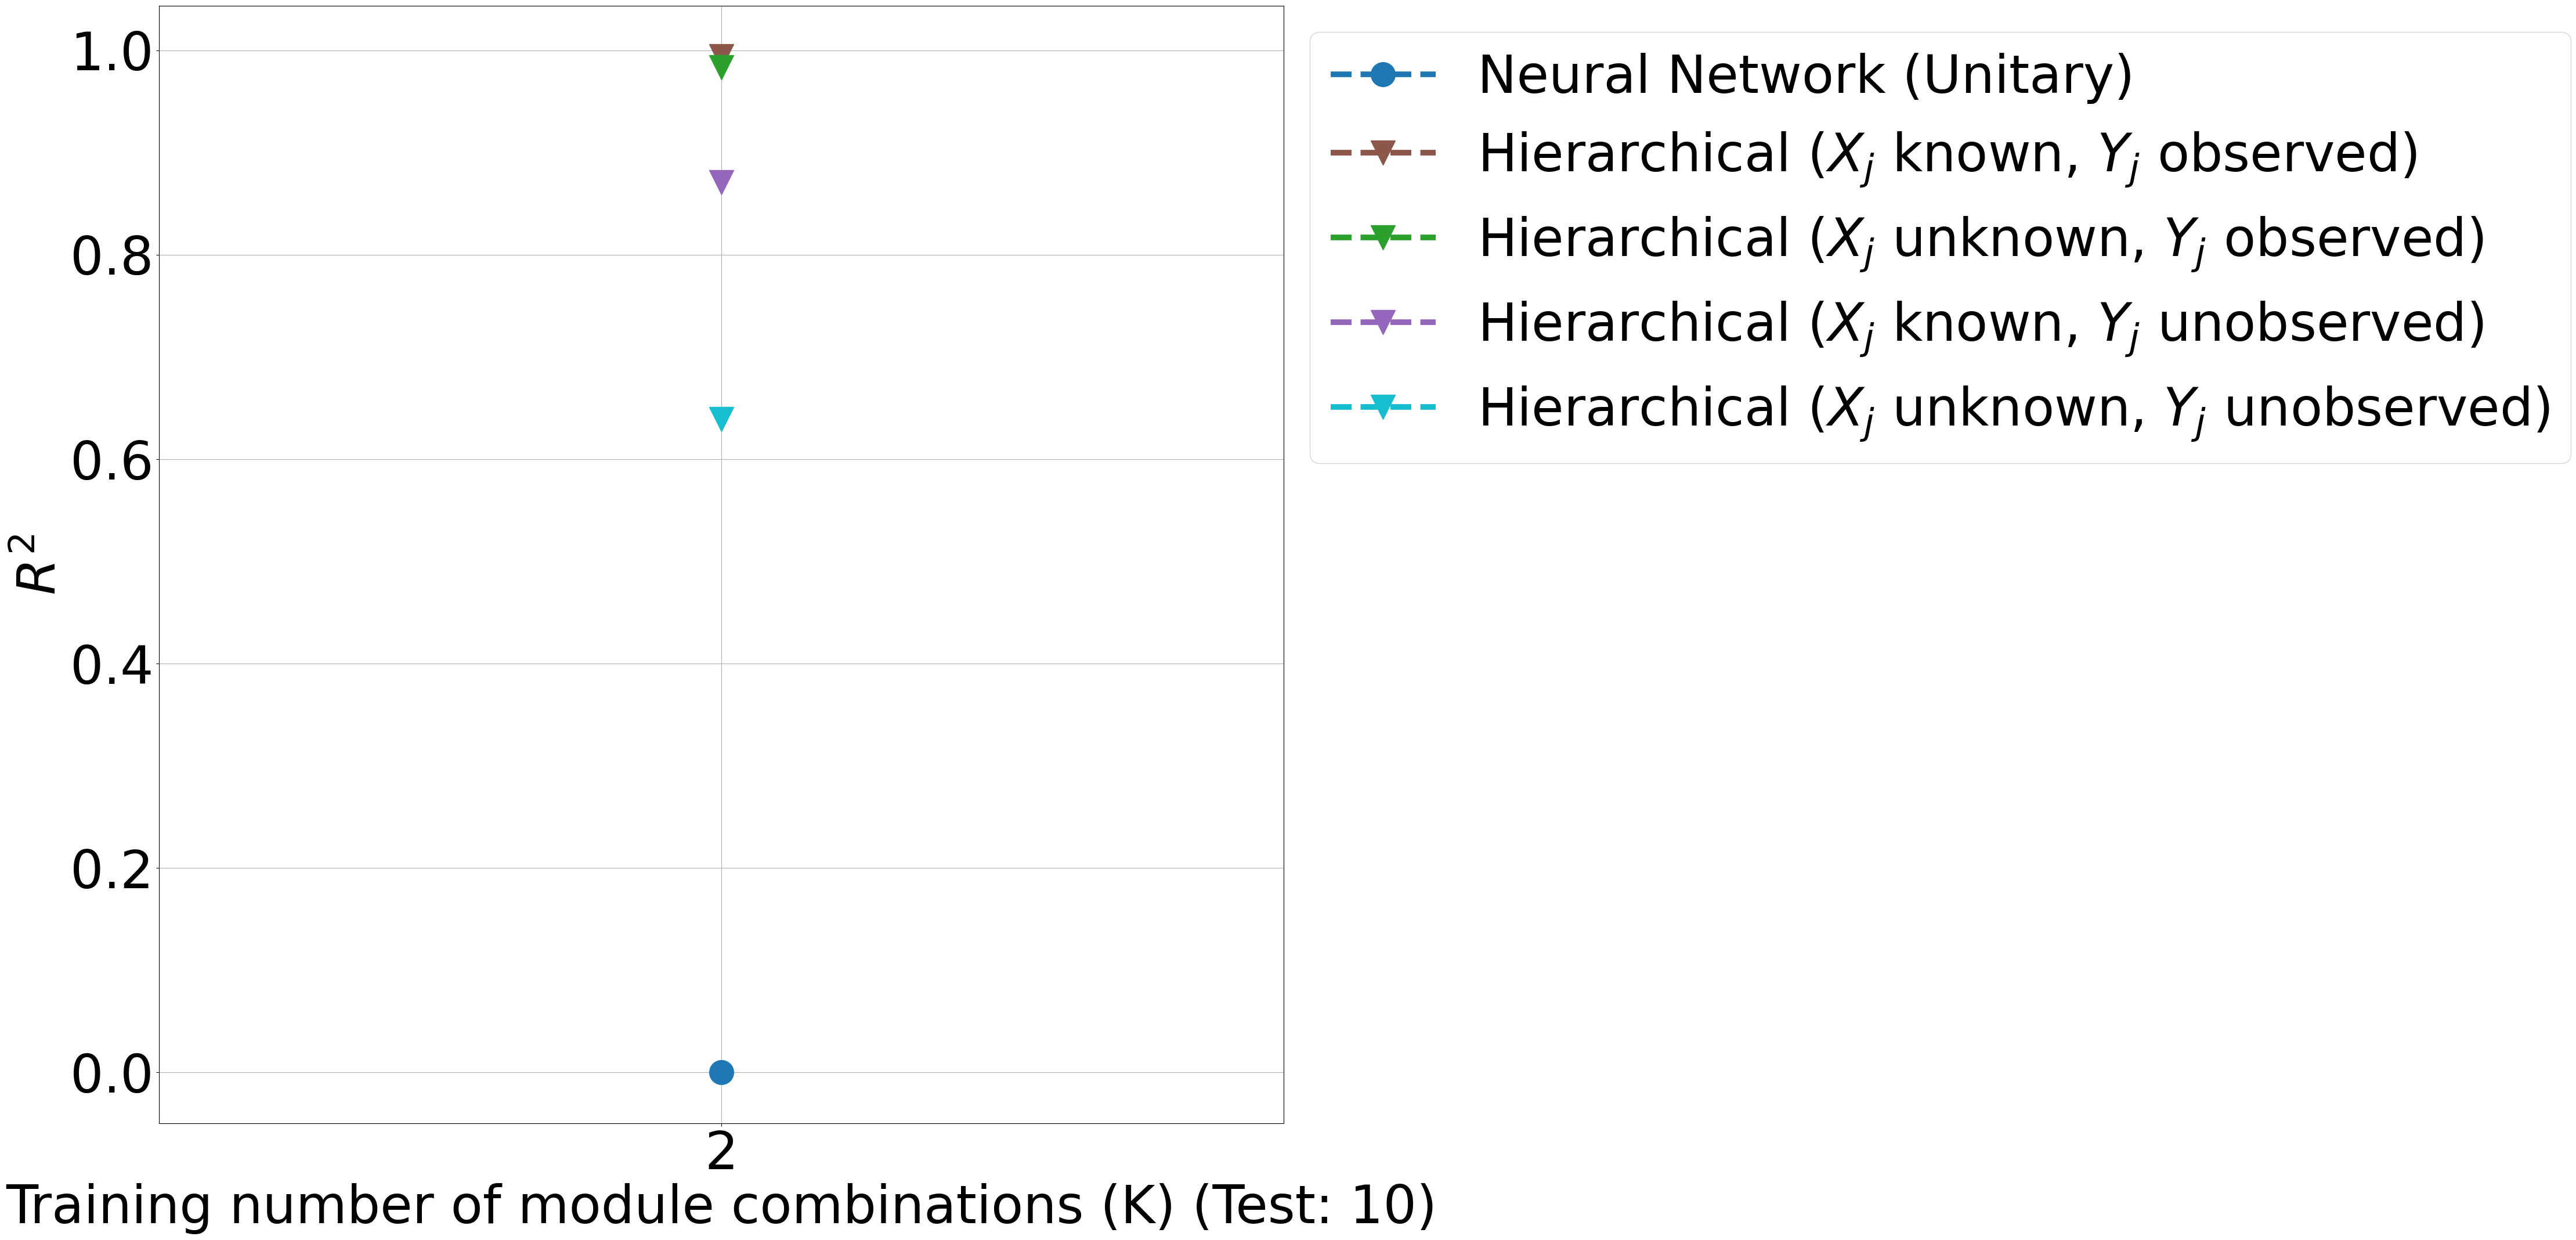

In [30]:
# Colors for each model
from matplotlib import pyplot as plt
import numpy as np
exp = "CG"
args = {}
args["number_of_modules"] = 5
import math
import os

from matplotlib import pyplot as plt
from matplotlib import ticker

font_size = 65
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
markersize = 30
colors = {
    'Baseline': '#1f77b4',
    'MoE': 'green',
    'Catenets': '#bcbd22',
    'Sequential_unknown_cov': '#2ca02c',
    'End_to_End_unknown_cov': '#17becf',
    'Sequential_known_cov': '#8c564b',
    'End_to_End_known_cov': '#9467bd',
    'XLearner': '#7f7f7f',
    'TLearner': '#17becf',
    'SLearner': '#bcbd22',
    'RandomForest': '#8c564b',
    'NonParamDML': '#d62728',
}
linewidth = 7


labels = {'Sequential_unknown_cov': r'Hierarchical ($X_j$ unknown, $Y_j$ observed)', 'Sequential_known_cov': r'Hierarchical ($X_j$ known, $Y_j$ observed)', 'End_to_End_unknown_cov': r'Hierarchical ($X_j$ unknown, $Y_j$ unobserved)', 'End_to_End_known_cov': r'Hierarchical ($X_j$ known, $Y_j$ unobserved)', 'Baseline': 'Neural Network (Unitary)','XLearner': 'X-learner', 'RandomForest': 'Random Forest', 'NonParamDML': 'NonParamDML', 'SLearner': 'S-learner', 'TLearner': 'T-learner'}
markers = {'Sequential_unknown_cov': 'v', 'Sequential_known_cov': 'v', 'End_to_End_unknown_cov': 'v', 'End_to_End_known_cov': 'v', 'Catenets': 'o', 'Baseline': 'o', 'XLearner': 'o', 'RandomForest': 'o', 'NonParamDML': 'o', 'SLearner': 'o', 'TLearner': 'o'}
fig, (ax1) = plt.subplots(1, 1, figsize=(25, 25))
# Function to plot performance
def plot_performance(metric, metric_name, data_type, axis):
    # fig1, ax1 = plt.subplots(figsize=(25, 20))
    
    # define x as list of keys 
    x = list(seq_results.keys())
    # convert string to float
    x = [int(i) for i in x]
    # remove key 5
    # x = [i for i in x if i != 5]
   
    
    for model in ['Baseline', 'Sequential_known_cov', 'Sequential_unknown_cov', 'End_to_End_known_cov', 'End_to_End_unknown_cov']:
        y = [seq_results[str(key)][f'{model}_{data_type}'][metric] for key in x]
        print(y)
        # replace negative values with 0
        y = [0 if i < 0 else i for i in y]
        # log scale for PEHE
        if metric_name == 'PEHE':
            # y = [math.sqrt(i) for i in y]
            y = [math.log(i+1) for i in y]
        # if exp == "noise":
        x_plot = np.array(x)
        # else:
        #     x_plot = 1-np.array(x)
        #     print(x_plot)
        #     x_plot = [i*5 for i in x_plot]
        print(x_plot)


        label_name = r'{}'.format(labels[model])
        axis.plot(x_plot, y, color=colors[model], label=label_name,
                 linestyle='-' if data_type == 'train' else '--', marker=markers[model], markersize=markersize, linewidth=linewidth)

        
    
    plt.xlabel('Training number of module combinations (K) (Test: 10)')
    if metric_name == 'PEHE':
         metric_title = r'$\epsilon_{PEHE} (log-scale)$'
    elif metric_name == 'R^2':
        metric_title = r'$R^2$'
    axis.set_ylabel(metric_title)
    # y-axis in log scale
    # plt.yscale('log')
    
    # set x-axis ticks as x_plot
    axis.set_xticks(x_plot)
    
    # plt.title(f'{metric_title} Performance ({data_type.capitalize()})')
    # legend outside plot
    
# Plot PEHE for train and test
# plot_performance(0, 'PEHE', 'train')
plot_performance(1, 'R^2', 'test', ax1)


plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=font_size)    
plt.grid(True)
plt.savefig("plots/sequential_varying_data_access.pdf", bbox_inches='tight')



# Parallel Compositional Generalization

[-0.6870059118451015]
[2]
[0.7745472670998164]
[2]
[0.9826780368061364]
[2]
[0.9522956882048332]
[2]


KeyError: 'XLearner_test'

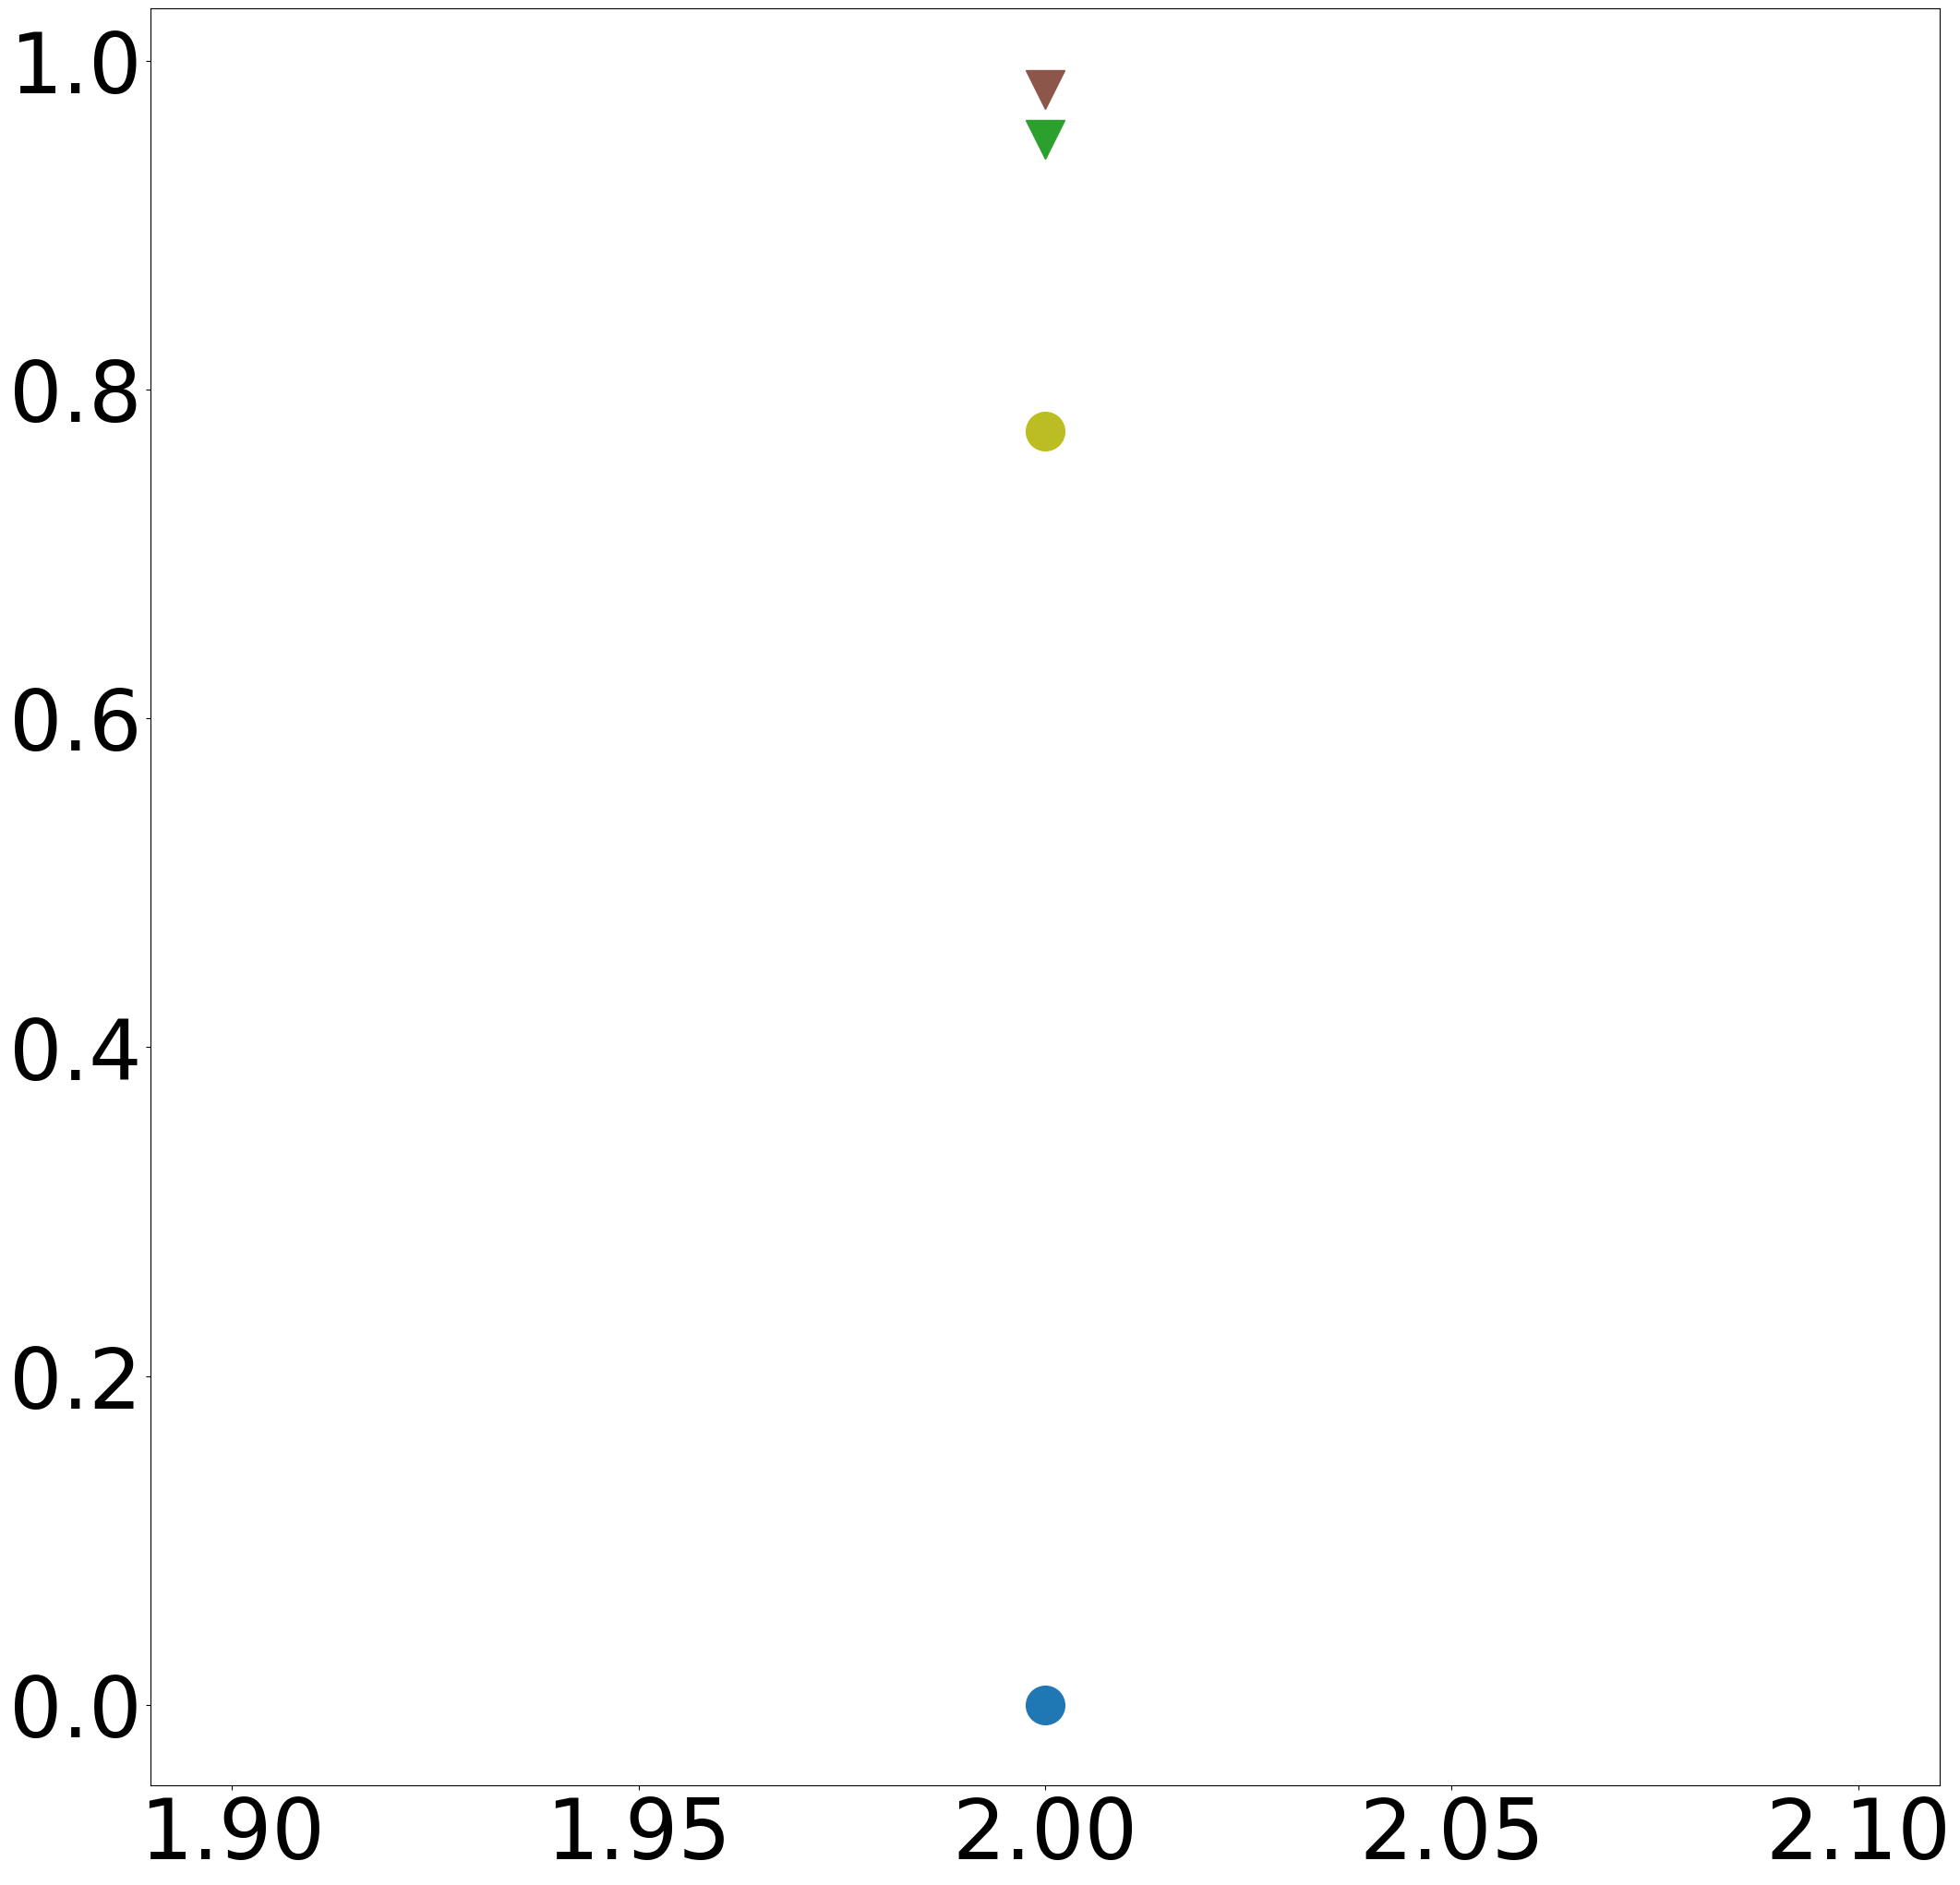

In [31]:
colors_parallel = {
    'Baseline': '#1f77b4',
    'MoE': '#17becf',
    'MoEknownCov': '#9467bd',
    'Catenets': '#bcbd22',
    'Additive_unknown_cov': '#2ca02c',
    'Additive_known_cov': '#8c564b',
    'XLearner': '#7f7f7f',
    'TLearner': '#17becf',
    'SLearner': '#bcbd22',
    'RandomForest': '#8c564b',
    'NonParamDML': '#d62728',
    
    
}
linewidth = 7


labels_parallel = {'Additive_unknown_cov': r'Parallel ($X_j$ unknown, $Y_j$ observed)', 'Additive_known_cov': r'Parallel ($X_j$ known, $Y_j$ observed)', 'MoE': r'Parallel ($X_j$ unknown, $Y_j$ unobserved)', 'MoEknownCov': r'Parallel ($X_j$ known, $Y_j$ unobserved)', 'Catenets': 'TNet (Unitary)', 'Baseline': 'Neural Network (Unitary)', 'XLearner': 'X-learner', 'RandomForest': 'Random Forest', 'NonParamDML': 'NonParamDML', 'SLearner': 'S-learner', 'TLearner': 'T-learner'}
markers_parallel = {'Additive_unknown_cov': 'v', 'Additive_known_cov': 'v', 'MoE': 'v', 'MoEknownCov': 'v', 'Catenets': 'o', 'Baseline': 'o', 'XLearner': 'o', 'RandomForest': 'o', 'NonParamDML': 'o', 'SLearner': 'o', 'TLearner': 'o'}
fig, (ax1) = plt.subplots(1, 1, figsize=(25, 25))
# Function to plot performance
def plot_performance_parallel(metric, metric_name, data_type, axis):
    # fig1, ax1 = plt.subplots(figsize=(25, 20))
    
    x = list(parallel_results.keys())
    # convert string to float
    x = [int(i) for i in x]
    # remove key 5
    # x = [i for i in x if i != 5]
   
    
    for model in ['Baseline', 'Catenets', 'Additive_known_cov', 'Additive_unknown_cov',  'XLearner']:
        y = [parallel_results[str(key)][f'{model}_{data_type}'][metric] for key in x]
        print(y)
        # replace negative values with 0
        y = [0 if i < 0 else i for i in y]
        # log scale for PEHE
        if metric_name == 'PEHE':
            # y = [math.sqrt(i) for i in y]
            y = [math.log(i+1) for i in y]
        # if exp == "noise":
        x_plot = np.array(x)
        # else:
        #     x_plot = 1-np.array(x)
        #     print(x_plot)
        #     x_plot = [i*5 for i in x_plot]
        print(x_plot)


        label_name = r'{}'.format(labels_parallel[model])
        axis.plot(x_plot, y, color=colors_parallel[model], label=label_name,
                 linestyle='-' if data_type == 'train' else '--', marker=markers_parallel[model], markersize=markersize, linewidth=linewidth)

        
    
    plt.xlabel('Training number of module combinations (K) (Test: 10)')
    if metric_name == 'PEHE':
        metric_title = r'$PEHE (log-scale)$'
    elif metric_name == 'R^2':
        metric_title = r'$R^2$'
    axis.set_ylabel(metric_title)
    # y-axis in log scale
    # plt.yscale('log')
    
    # set x-axis ticks as x_plot
    axis.set_xticks(x_plot)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=font_size)
plot_performance_parallel(1, 'R^2', 'test', ax1)
plt.savefig("plots/parallel_varying_data_access.pdf", bbox_inches='tight')

# Combined Results for Sequential and Parallel

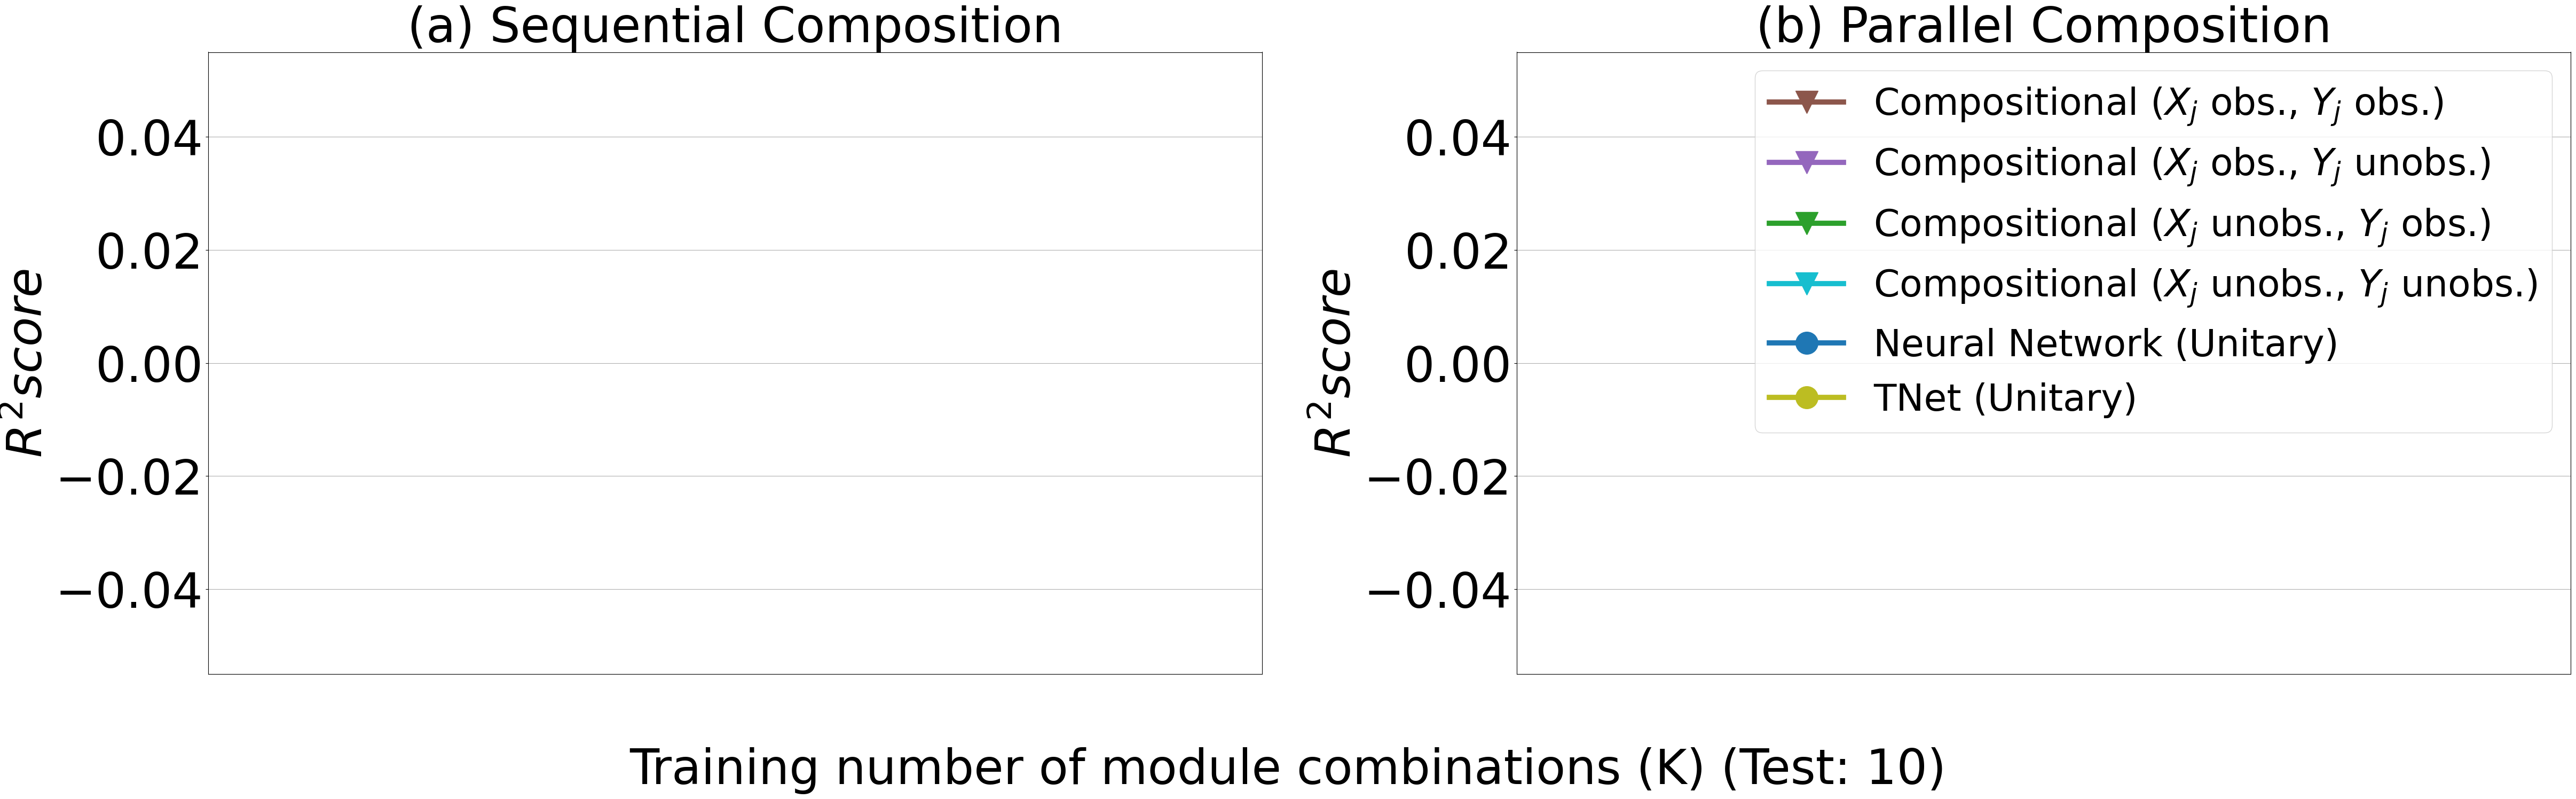

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Plot settings
font_size = 65
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': 50,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size
})
markersize = 30
linewidth = 7

# Colors and styles for both model types
colors = {
    'Baseline': '#1f77b4',
    'MoE': 'green',
    'Catenets': '#bcbd22',
    'Sequential_unknown_cov': '#2ca02c',
    'End_to_End_unknown_cov': '#17becf',
    'Sequential_known_cov': '#8c564b',
    'End_to_End_known_cov': '#9467bd',
    'XLearner': '#7f7f7f'
}

labels = {
    'Sequential_unknown_cov': r'Compositional ($X_j$ unobs., $Y_j$ obs.)',
    'Sequential_known_cov': r'Compositional ($X_j$ obs., $Y_j$ obs.)',
    'End_to_End_unknown_cov': r'Compositional ($X_j$ unobs., $Y_j$ unobs.)',
    'End_to_End_known_cov': r'Compositional ($X_j$ obs., $Y_j$ unobs.)',
    'Baseline': 'Neural Network (Unitary)',
    'XLearner': 'X-learner (Unitary)',
    'Catenets': 'TNet (Unitary)'
}

colors_parallel = {
    'Baseline': '#1f77b4',
    'MoE': '#17becf',
    'MoEknownCov': '#9467bd',
    'Catenets': '#bcbd22',
    'Additive_unknown_cov': '#2ca02c',
    'Additive_known_cov': '#8c564b',
    'XLearner': '#7f7f7f'
}

labels_parallel = {
    'Additive_unknown_cov': r'Compositional ($X_j$ unobs., $Y_j$ obs.)',
    'Additive_known_cov': r'Compositional ($X_j$ obs., $Y_j$ obs.)',
    'MoE': r'Compositional ($X_j$ unobs., $Y_j$ unobs.)',
    'MoEknownCov': r'Compositional ($X_j$ obs., $Y_j$ unobs.)',
    'Catenets': 'TNet (Unitary)',
    'Baseline': 'Neural Network (Unitary)',
    'XLearner': 'X-learner (Unitary)',

}

markers = {
    'Sequential_unknown_cov': 'v', 'Sequential_known_cov': 'v',
    'End_to_End_unknown_cov': 'v', 'End_to_End_known_cov': 'v',
    'Catenets': 'o', 'Baseline': 'o', 'XLearner': 'o'
}

markers_parallel = {
    'Additive_unknown_cov': 'v', 'Additive_known_cov': 'v',
    'MoE': 'v', 'MoEknownCov': 'v',
    'Catenets': 'o', 'Baseline': 'o', 'XLearner': 'o'
}

sequential_order = [
    'Sequential_known_cov',          # Brown triangles
    'Sequential_unknown_cov',        # Green triangles
    'End_to_End_known_cov',         # Purple triangles
    'End_to_End_unknown_cov',       # Cyan triangles
    # 'XLearner',                     # Gray circles
    'Baseline',                     # Blue circles
    'Catenets'                      # Yellow circles
]

parallel_order = [
    'Additive_known_cov',           # Brown triangles
    # 'MoEknownCov',                  # Purple triangles
    'Additive_unknown_cov',         # Green triangles
    
    # 'MoE',   
    # 'XLearner',                         # Cyan triangles
    'Baseline',                     # Blue circles
    'Catenets',                     # Yellow circles
                        # Gray circles
]

# Create figure with two subplots and space at bottom for legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 18))

def plot_performance(metric, metric_name, data_type, axis, all_results, is_parallel=False):
    x = list(all_results.keys())[1:] if not is_parallel else list(all_results.keys())[1:]
    x = [int(i) for i in x]
    
    models = parallel_order if is_parallel else sequential_order
    
    for model in models:
        y = [all_results[str(key)][f'{model}_{data_type}'][metric] for key in x]
        y = [0 if i < 0 else i for i in y]
        
        if metric_name == 'PEHE':
            y = [math.log(i+1) for i in y]
        
        x_plot = np.array(x)
        
        label_name = r'{}'.format(labels_parallel[model] if is_parallel else labels[model])
        color = colors_parallel[model] if is_parallel else colors[model]
        marker = markers_parallel[model] if is_parallel else markers[model]
        # if model == "MoE":
        #     print(y)
        # print(len(x_plot), len(y))
        axis.plot(x_plot, y, color=color, label=label_name,
                 linestyle='-' if data_type == 'train' else '-',
                 marker=marker, markersize=markersize, linewidth=linewidth)
    
    metric_title = r'$\epsilon_{PEHE}$ (log-scale)' if metric_name == 'PEHE' else r'$R^2 score$'
    axis.set_ylabel(metric_title)
    axis.set_xticks(x_plot)
    axis.grid(True)
    # axis.set_xticklabels([f'{i}' for i in x_plot if i != 10])

# Plot both types of models
plot_performance(1, 'R^2', 'test', ax1, seq_results)
ax1.set_title('(a) Sequential Composition')

plot_performance(1, 'R^2', 'test', ax2, parallel_results, is_parallel=True)
ax2.set_title('(b) Parallel Composition')

# Get unique labels by combining both plots' legends and removing duplicates
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Create dictionary to store unique labels and their handles
unique_labels = {}
for handle, label in zip(handles1 + handles2, labels1 + labels2):
    if label not in unique_labels:
        unique_labels[label] = handle

# Sort labels to group similar items together
sorted_labels = sorted(unique_labels.keys())
sorted_handles = [unique_labels[label] for label in sorted_labels]

# Add common x-axis label
fig.text(0.5, 0.15, 'Training number of module combinations (K) (Test: 10)', 
         ha='center', va='center', fontsize=font_size)

# Adjust subplot spacing to make room for legend and common x-label
plt.subplots_adjust(bottom=0.25)

# Place unified legend below the subplots
ax2.legend(sorted_handles, sorted_labels,
          loc='upper right', ncol=1)

plt.tight_layout()
# Adjust after tight_layout to ensure legend placement is preserved
plt.subplots_adjust(bottom=0.25)

# have last x-axis label as "10 (WID)"


plt.savefig("plots/combined_compositional.pdf", bbox_inches='tight', dpi=300)
# plt.show()